# Stage 2 — Exploratory data analysis

Missing values, outliers, correlations, sensor behaviour, and the difference
between normal and faulty operating conditions.

## A note on feature engineering, before the plots

The five raw sensors are not the quantities that govern failure. Power is. Heat
rejection capacity is. Accumulated strain is. So this stage derives them:

| Derived quantity | Formula | Physical meaning |
|---|---|---|
| `mechanical_power_W` | `torque × speed × 2π/60` | Power delivered at the spindle |
| `temp_differential_K` | `process − air` | The gradient driving heat rejection |
| `wear_torque_strain_minNm` | `tool_wear × torque` | Load-weighted time in service |
| `torque_per_rpm` | `torque / speed` | Specific loading — hard cutting while turning slowly |
| `cooling_load_index` | `power / temp_differential` | Watts to shed per kelvin available |

**What is deliberately not computed.** AI4I's labels were generated by
threshold rules over these same quantities — a heat-dissipation failure is
recorded when the differential is below 8.6 K *and* speed is below 1380 rpm, for
instance. Encoding those thresholds as features would produce near-perfect
scores and would be, correctly, dismissed as circular by anyone who knows the
dataset. So there are **no threshold flags, no type-specific limits, no
margin-to-threshold distances** here. The models must discover the operating
limits from data.


In [1]:
import sys, warnings
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src import config as cfg, data, features, eda, models, evaluate, anomaly, explain, viz
viz.apply_style()
pd.set_option("display.width", 130)
pd.set_option("display.max_columns", 40)


In [2]:
df = features.add_physics_features(data.add_targets(data.load_raw()))
df[cfg.ENGINEERED_COLS].describe().T

,count,mean,std,min,25%,50%,75%,max
mechanical_power_W,10000.0,6279.744953,1067.418295,1148.440610,5561.184484,6271.027344,7003.002724,10469.923005
temp_differential_K,10000.0,10.000630,1.001094,7.600000,9.300000,9.800000,11.000000,12.100000
wear_torque_strain_minNm,10000.0,4314.664550,2826.567692,0.000000,1963.650000,4012.950000,6279.000000,16497.000000
torque_per_rpm,10000.0,0.026895,0.008838,0.001317,0.020640,0.026735,0.032805,0.063833
cooling_load_index,10000.0,634.321645,126.271130,111.862940,545.039327,627.116693,715.498706,1224.173937


## 1. Missing values

Already established in Stage 1, restated because EDA should not assume it:


In [3]:
print("missing values per column:")
print(df[cfg.SENSOR_COLS + cfg.ENGINEERED_COLS].isna().sum().to_string())
print("\nno imputation required — the SimpleImputer in the pipeline is defensive only")

missing values per column:
Air temperature [K]         0
Process temperature [K]     0
Rotational speed [rpm]      0
Torque [Nm]                 0
Tool wear [min]             0
mechanical_power_W          0
temp_differential_K         0
wear_torque_strain_minNm    0
torque_per_rpm              0
cooling_load_index          0

no imputation required — the SimpleImputer in the pipeline is defensive only


## 2. Outliers

The important question is not "are there statistical outliers" but "are they
errors or real extreme operation?" In a machine dataset, extreme readings are
usually the *interesting* rows, not bad data.


In [4]:
rows = []
for col in cfg.SENSOR_COLS + cfg.ENGINEERED_COLS:
    q1, q3 = df[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    lo, hi = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    mask = (df[col] < lo) | (df[col] > hi)
    rows.append({
        "quantity": col,
        "IQR outliers": int(mask.sum()),
        "share_%": round(100 * mask.mean(), 2),
        "failure rate among them_%": round(100 * df.loc[mask, "y_failure"].mean(), 2)
                                      if mask.any() else 0.0,
        "fleet failure rate_%": round(100 * df["y_failure"].mean(), 2),
    })
pd.DataFrame(rows)

,quantity,IQR outliers,share_%,failure rate among them_%,fleet failure rate_%
0,Air temperature [K],0,0.00,0.00,3.39
1,Process temperature [K],0,0.00,0.00,3.39
2,Rotational speed [rpm],418,4.18,8.37,3.39
3,Torque [Nm],69,0.69,89.86,3.39
4,Tool wear [min],0,0.00,0.00,3.39
5,mechanical_power_W,60,0.60,100.00,3.39
6,temp_differential_K,0,0.00,0.00,3.39
7,wear_torque_strain_minNm,20,0.20,100.00,3.39
8,torque_per_rpm,61,0.61,72.13,3.39
9,cooling_load_index,96,0.96,68.75,3.39


This table is the argument for keeping every row. Rotational speed has the
largest outlier population, and the failure rate *among* those outliers is
several times the fleet rate. These are not sensor glitches — they are machines
running at the edge of their envelope, which is exactly the population the
system exists to catch. **Nothing is clipped or removed.**

## 3. Class balance — the headline constraint


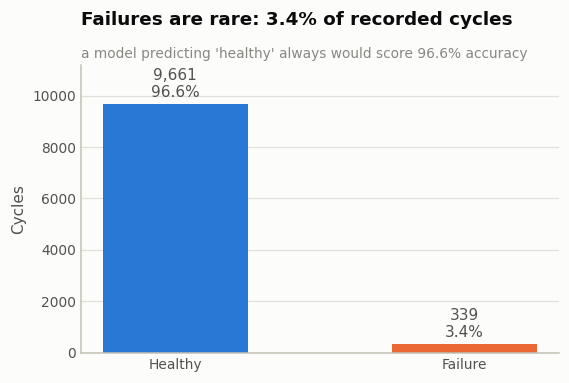

In [5]:
ax = eda.plot_class_balance(df)
plt.show()

3.39% positives. A model that predicts "healthy" for every machine scores
96.6% accuracy and prevents zero breakdowns, which is why every metric in this
project is a rare-event metric: PR-AUC, recall at fixed precision, and expected
maintenance cost.

## 4. Normal vs faulty operating conditions

The distribution of every measured and derived quantity, split by outcome.


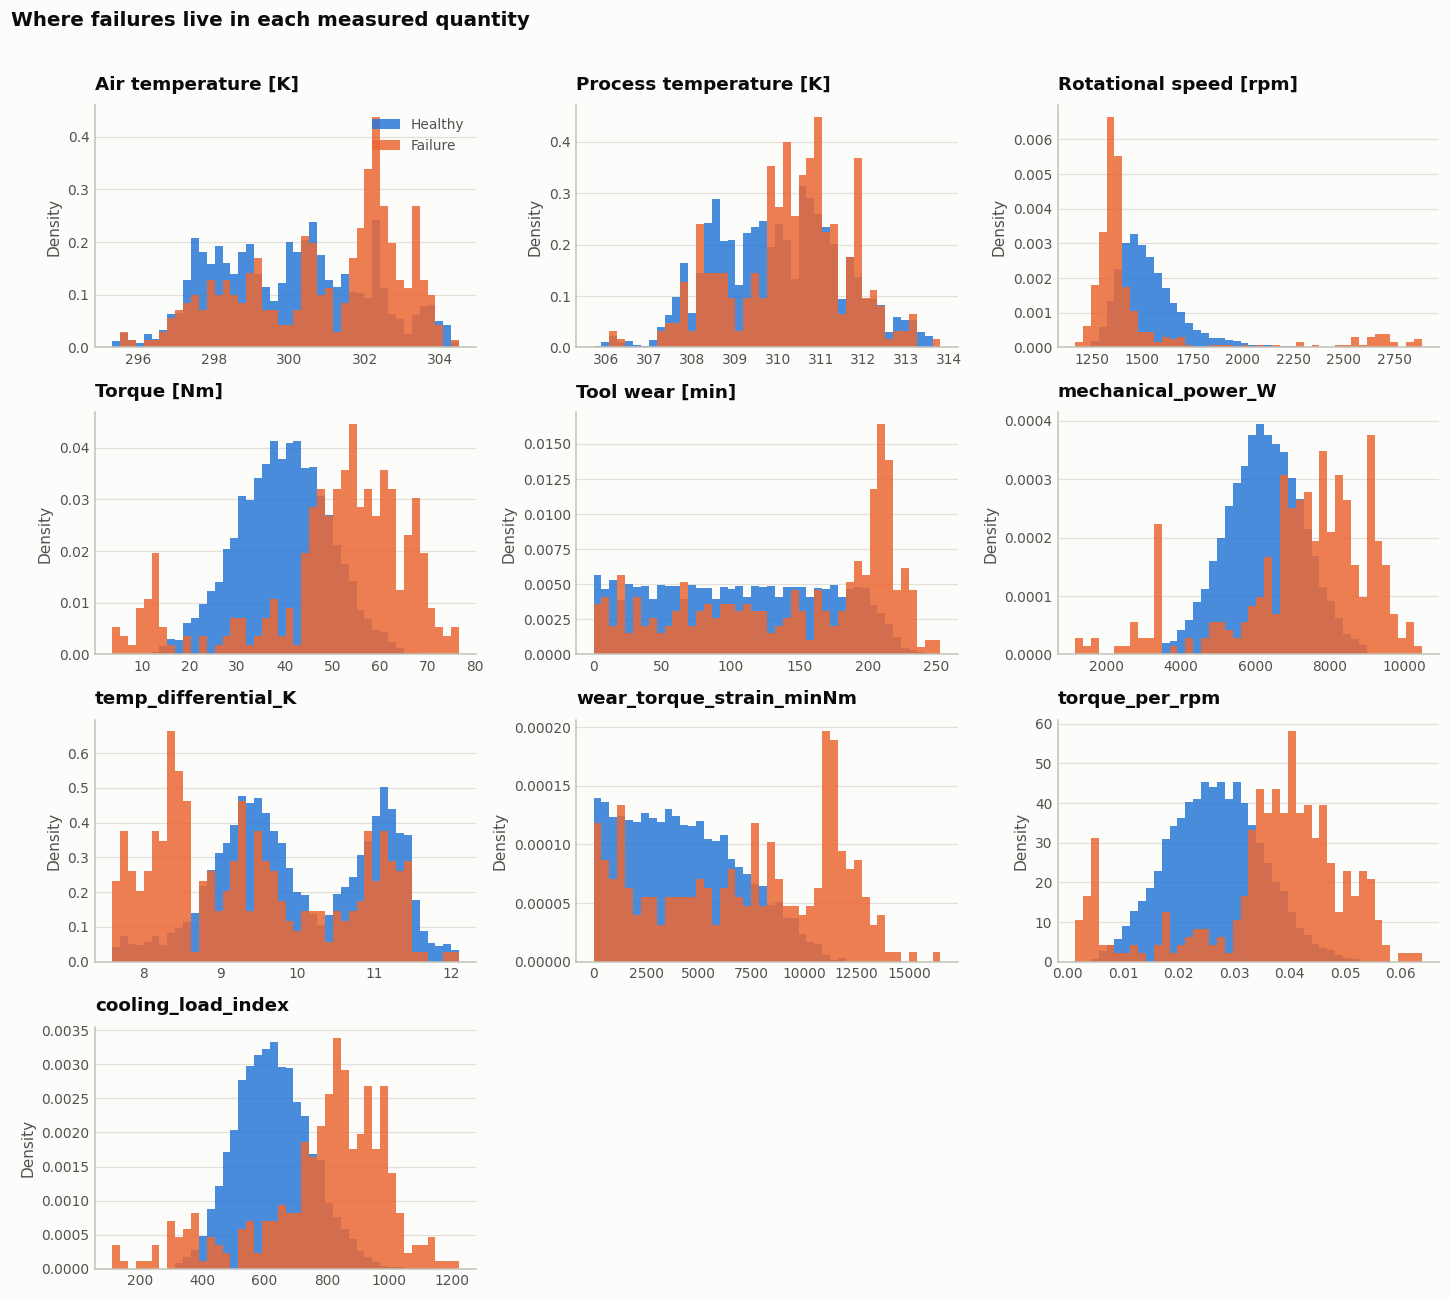

In [6]:
fig, _ = eda.plot_sensor_distributions(df)
plt.show()

Reading these panels:

- **Air and process temperature** barely separate on their own. Absolute
  temperature is nearly irrelevant.
- **Their difference** separates clearly — failures concentrate where the
  differential is small. It is the *gradient*, not the level, that matters.
- **Torque** and **tool wear** both shift right for failures, as expected.
- **Rotational speed** is bimodal for failures: both very low and very high
  speeds are dangerous. A linear model cannot represent this, which is exactly
  why logistic regression will underperform in Stage 3.
- **Wear × torque strain** shows the cleanest separation of all — a 70% shift in
  the mean between healthy and failed.


In [7]:
shift = eda.summary_table(df)
shift.style.format({"healthy_mean": "{:,.3f}", "failed_mean": "{:,.3f}",
                    "shift_%": "{:+.1f}"})

,quantity,healthy_mean,failed_mean,shift_%
0,wear_torque_strain_minNm,"4,213.843","7,187.938",+70.6
1,torque_per_rpm,0.027,0.037,+38.0
2,Tool wear [min],106.694,143.782,+34.8
3,Torque [Nm],39.630,50.168,+26.6
4,cooling_load_index,628.999,786.011,+25.0
5,mechanical_power_W,"6,244.548","7,282.819",+16.6
6,temp_differential_K,10.022,9.404,-6.2
7,Rotational speed [rpm],"1,540.260","1,496.487",-2.8
8,Air temperature [K],299.974,300.886,+0.3
9,Process temperature [K],309.996,310.290,+0.1


## 5. Correlation structure


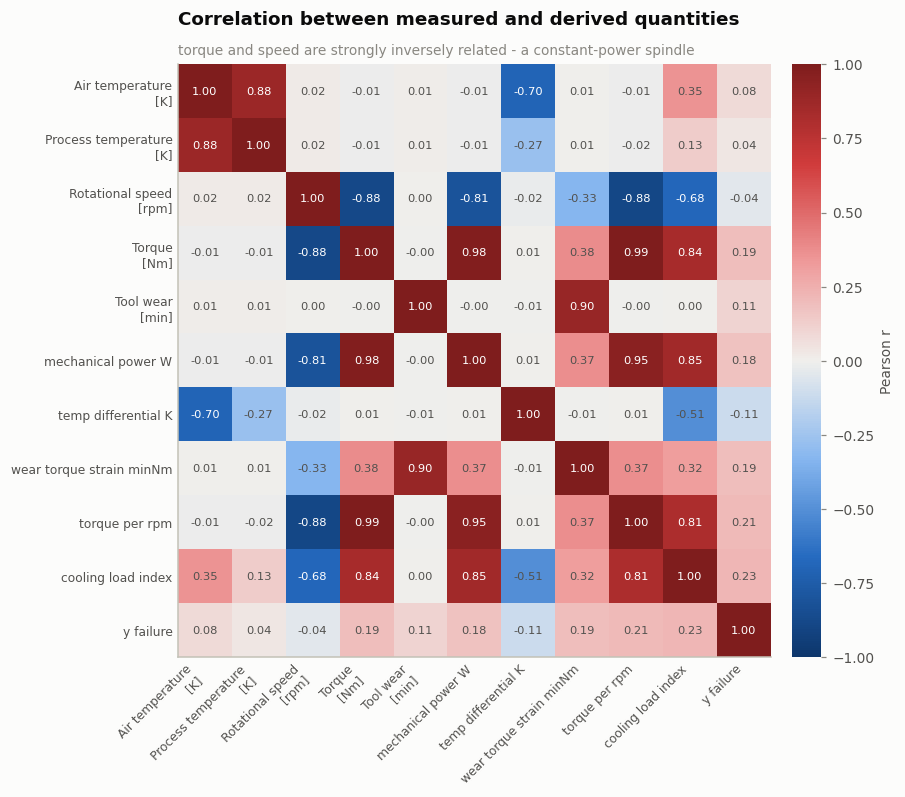

In [8]:
ax = eda.plot_correlation(df)
plt.show()

Two things to take from this:

**Torque and speed are strongly inversely correlated (≈ −0.88).** This is a
roughly constant-power spindle: to cut harder it turns slower. So the raw pair
carries largely redundant information, while their *product* — power — carries
something neither does alone. This is the quantitative justification for the
feature engineering.

**No single quantity correlates strongly with failure.** The best is the strain
product at around 0.2. Failure is not a threshold on one sensor; it is a region
in a multi-dimensional space, which is why this needs a model rather than an
alarm limit.

## 6. The operating envelope


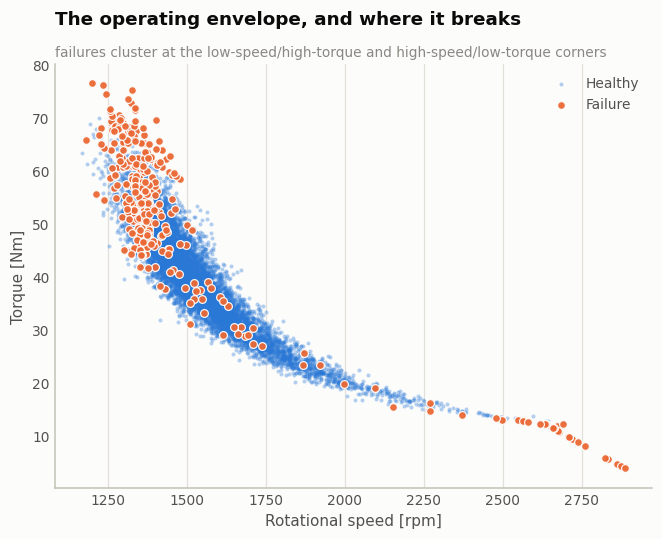

In [9]:
ax = eda.plot_operating_envelope(df)
plt.show()

This is the single most informative figure in the analysis. The healthy cloud
traces the constant-power hyperbola, and failures sit in two distinct corners:

- **Low speed, high torque** — overstrain and heat dissipation territory
- **High speed, low torque** — the low-power end of the power-failure band

A linear decision boundary cannot separate two opposite corners from the middle.
This figure predicts the Stage 3 result before a single model is fitted.

## 7. Degradation with tool wear


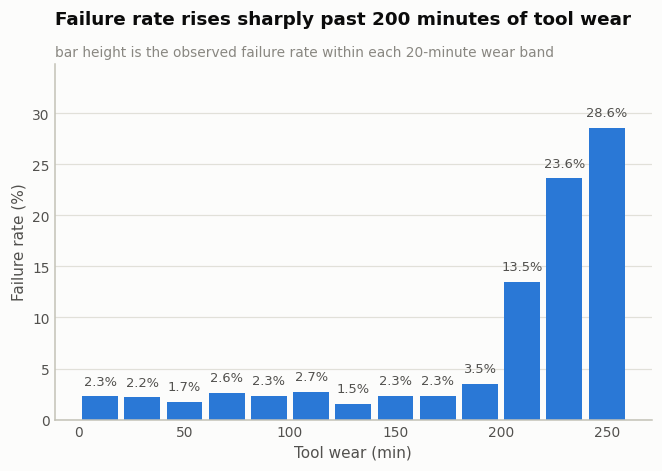

In [10]:
ax = eda.plot_wear_vs_failure(df)
plt.show()

The closest thing this dataset has to a degradation curve. Failure rate is flat
and low for most of tool life, then climbs steeply past roughly 200 minutes.

Note carefully what this is *not*: each row is an independent cycle snapshot,
not a tracked machine over time. So this is a population-level hazard curve, not
a run-to-failure trajectory — which is why Stage 5 predicts failure state rather
than remaining useful life.

## 8. Machine quality variant


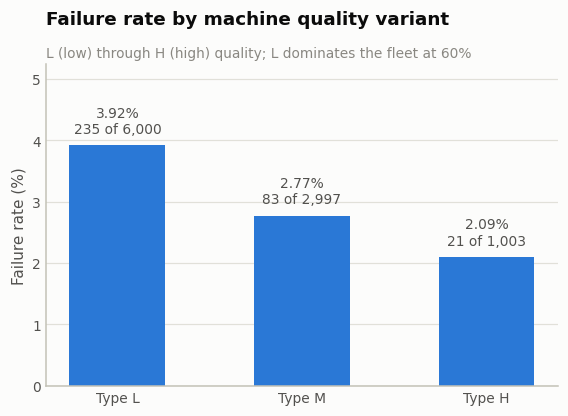

In [11]:
ax = eda.plot_type_breakdown(df)
plt.show()

In [12]:
print(df.groupby(cfg.COL_TYPE, observed=True)
        .agg(n=("y_failure", "size"), failures=("y_failure", "sum"),
             rate_pct=("y_failure", lambda s: round(100 * s.mean(), 2)),
             mean_strain=(cfg.FEAT_STRAIN, "mean"))
        .reindex(cfg.TYPE_ORDER).to_string())

         n  failures  rate_pct  mean_strain
Type                                       
L     6000       235      3.92  4341.476133
M     2997        83      2.77  4272.300567
H     1003        21      2.09  4280.861316


## What Stage 2 established

- No missing values; **no rows removed** — the statistical outliers are the
  high-risk population, not errors
- Failures are 3.39% of cycles, so rare-event metrics only
- Absolute temperatures are nearly useless; the **differential** matters
- Torque and speed are ≈ −0.88 correlated — their **product** is the informative
  quantity
- Failures occupy **two opposite corners** of the speed/torque envelope, so the
  decision boundary is non-linear
- Failure hazard climbs sharply past **200 minutes** of tool wear
- No single quantity exceeds |r| ≈ 0.2 against failure — this needs a model

Next: Stage 3 fits three baselines and selects an operating point on
maintenance cost.
